# Plant Disease Detection 

## EDA 

In [1]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [2]:
# import Libraries

import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

In [3]:
# Load dataset 
 
data = "data"

# Cheking how big dataset is

total_images = 0

for folder in os.listdir(data):
    folder_path = os.path.join(data, folder)

    if os.path.isdir(folder_path):
        total_images += len(os.listdir(folder_path))

print("Total number of images:", total_images)

# List Clases 

classes = os.listdir(data)
print("Total number of classes:", len(classes))
print("class names:", classes[:10])



Total number of images: 9307
Total number of classes: 13
class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Rice __LeafBlast', 'Rice ___BrownSpot', 'Rice ___Healthy']


In [4]:
# Count Images in Each Class

image_count = {}

for cls in classes:
    class_path = os.path.join(data, cls)
    image_count[cls] = len(os.listdir(class_path))

print("Total Images per Class:",image_count)

# Cheking which class has lowest images which has highest images

class_counts = {
    cls: len(os.listdir(os.path.join(data, cls)))
    for cls in classes
}

print('Min images in a class:', min(class_counts.values()))
print('Max images in a class:', max(class_counts.values()))


Total Images per Class: {'Apple___Apple_scab': 630, 'Apple___Black_rot': 621, 'Apple___Cedar_apple_rust': 275, 'Apple___healthy': 1645, 'Potato___Early_blight': 1000, 'Potato___healthy': 152, 'Potato___Late_blight': 1000, 'Rice __LeafBlast': 562, 'Rice ___BrownSpot': 377, 'Rice ___Healthy': 1072, 'Rice ___Hispa': 408, 'Strawberry___healthy': 456, 'Strawberry___Leaf_scorch': 1109}
Min images in a class: 152
Max images in a class: 1645


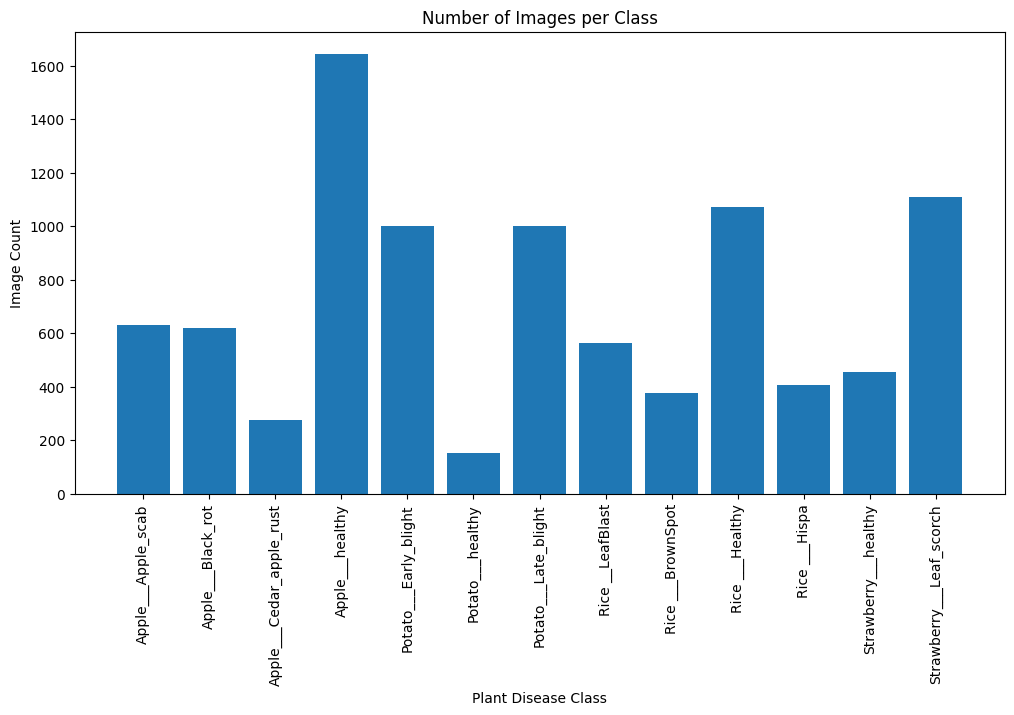

In [5]:
#Plot Class Distribution (Most Important EDA)

plt.figure(figsize=(12,6))
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.xlabel("Plant Disease Class")
plt.ylabel("Image Count")
plt.show()

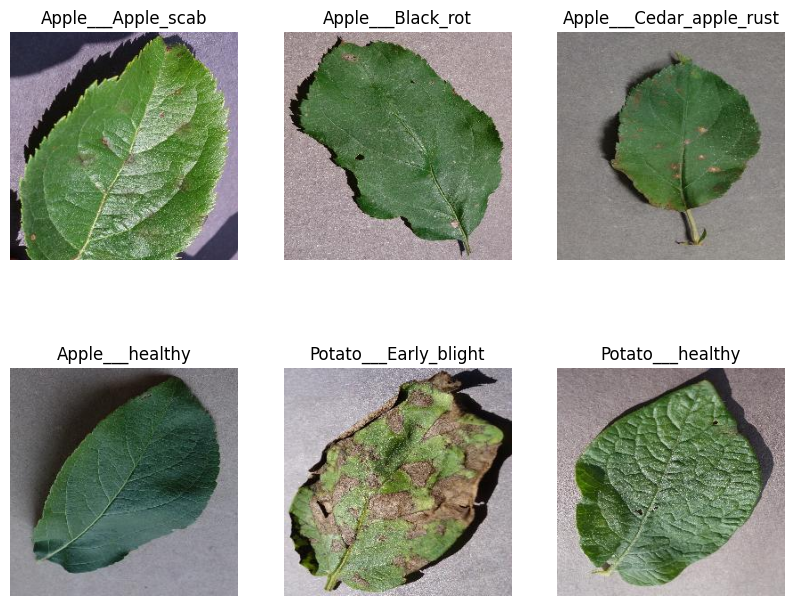

In [6]:
# Show Sample Images (Visual Inspection)

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes[:6]):
    class_path = os.path.join(data, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [7]:
# Check Image Sizes

widths = []
heights = []

for cls in classes[:5]:  # only first 5 classes to keep it simple
    class_path = os.path.join(data, cls)
    for img_name in os.listdir(class_path):
        img = Image.open(os.path.join(class_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(widths)
print(heights)

[256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256,

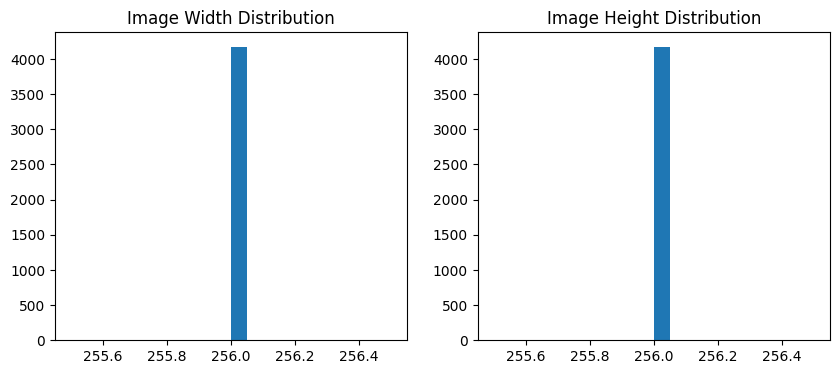

In [8]:
# Plot Image Size Distribution

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")

plt.show()

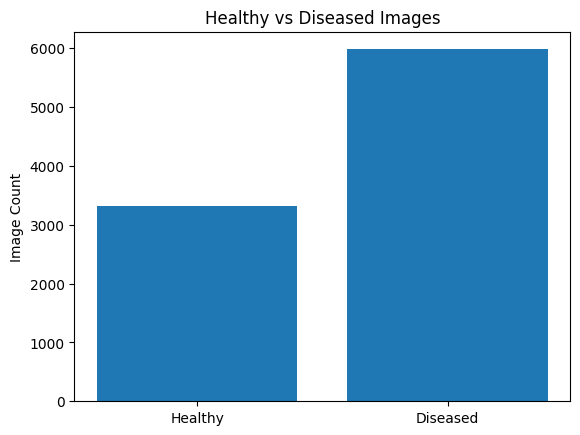

In [9]:
# Healthy vs Diseased Images Count

healthy = 0
diseased = 0

for cls in classes:
    if "healthy" in cls.lower():
        healthy += len(os.listdir(os.path.join(data, cls)))
    else:
        diseased += len(os.listdir(os.path.join(data, cls)))

plt.bar(["Healthy", "Diseased"], [healthy, diseased])
plt.title("Healthy vs Diseased Images")
plt.ylabel("Image Count")
plt.show()


## Model Building 

In [10]:
# Setting Hyperparameters 

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=30



In [11]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 9307 files belonging to 13 classes.


In [12]:
len(dataset)

291

In [13]:
# Making the partion of data into train, validation and test.

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=100):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
#  printing the length of data in particular part 

print("Length of train data:",len(train_ds))
print("Length of Validation data:",len(val_ds))
print("Length of test data:",len(test_ds))

Length of train data: 232
Length of Validation data: 29
Length of test data: 30


In [15]:
# Here we are using cache and prefetch to reduce the time in training

# cache is used to store the images in CPU.So, they do not have to look it every time in each epoch and they they can directly run it.
# prefetch is loading the next batch in CPU while running the previous one in GPU.

train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)

In [16]:
# Normalization of data
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [17]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 13

model = models.Sequential([
    resize_and_rescale,data_augmentation,
    layers.Conv2D(64, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

C:\Users\patel\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 13)               │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,725 (795.80 KB)

 Trainable params: 203,725 (795.80 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=30,
)

Epoch 1/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 898s 3s/step - accuracy: 0.3860 - loss: 1.7150 - val_accuracy: 0.5038 - val_loss: 1.6278
Epoch 2/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 766s 3s/step - accuracy: 0.5937 - loss: 1.0859 - val_accuracy: 0.6912 - val_loss: 0.8922
Epoch 3/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 942s 4s/step - accuracy: 0.6726 - loss: 0.8882 - val_accuracy: 0.6956 - val_loss: 0.8718
Epoch 4/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 821s 4s/step - accuracy: 0.7283 - loss: 0.7286 - val_accuracy: 0.7746 - val_loss: 0.5977
Epoch 5/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 842s 4s/step - accuracy: 0.7744 - loss: 0.5954 - val_accuracy: 0.8245 - val_loss: 0.4697
Epoch 6/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.8031 - loss: 0.5121 - val_accuracy: 0.7779 - val_loss: 0.5730
Epoch 7/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 713s 3s/step - accuracy: 0.8090 - loss: 0.5160 - val_accuracy: 0.8342 - val_loss: 0.4185
Epoch 8/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 705s 3s/step - accuracy: 0.8171 - loss: 0.4814 - val_accu

In [22]:
scores = model.evaluate(test_ds)

30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 518ms/step - accuracy: 0.8813 - loss: 0.3114


In [23]:
scores

[0.31138771772384644, 0.8812500238418579]

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

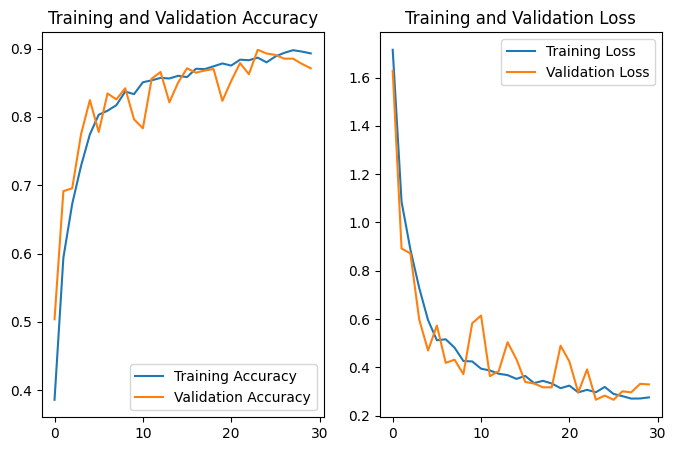

In [25]:
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Apple___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label: Apple___healthy


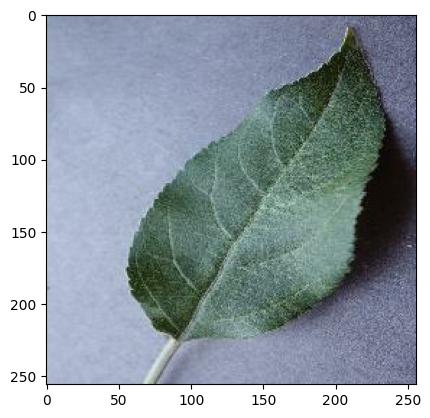

In [26]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",classes[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",classes[np.argmax(batch_prediction[0])])

In [27]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = classes[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


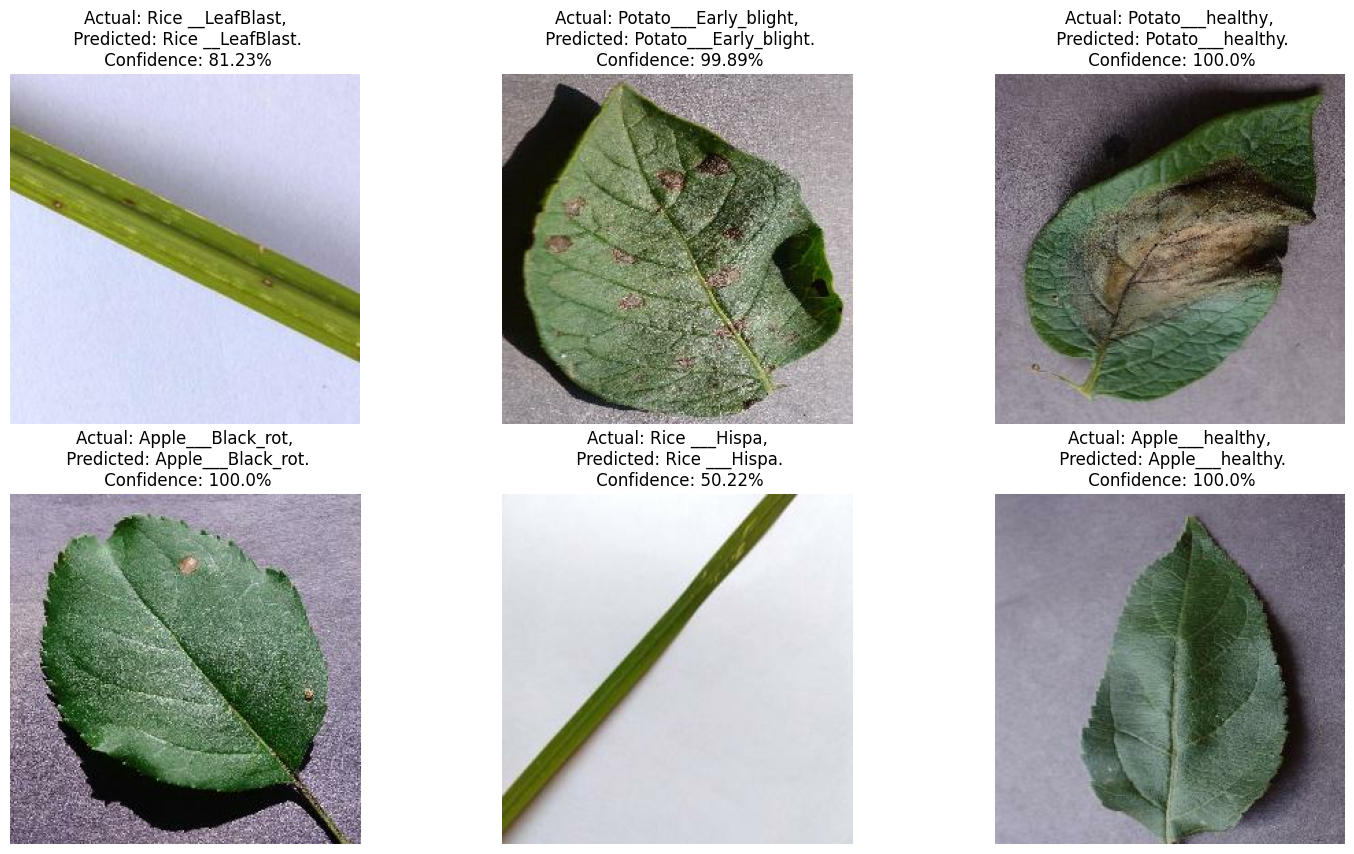

In [28]:
plt.figure(figsize=(18, 10))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = classes[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [29]:
# Get predictions from the model
y_pred = model.predict(val_ds)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get actual labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 528ms/step


In [30]:
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

[[ 9  3  0  9 15  5  1  2  1  4  8  4  5]
 [ 6  7  3 13 11  8  1  1  0  7  4  9  1]
 [ 1  1  2  6  4  4  0  3  1  5  2  2  1]
 [13 15 11 35 13 15  1  4  6 16 10 19  4]
 [10 14  2 22 10  6  1 10  4 11  4 12  9]
 [ 3 10  1 11 17 10  0  2  1 14  8 10  7]
 [ 0  0  0  3  2  1  0  2  1  2  2  0  2]
 [ 2  3  2 11  5  7  1  7  1  8  0  2  2]
 [ 0  4  0  9  6  3  4  2  1  4  0  4  0]
 [ 4 12  5 13 13 11  1  8  0 11  6 12  5]
 [ 3  0  2  7  6  5  0  3  0  2  2  3  2]
 [ 7 11  2 14  9 10  2  6  1 16  2 17  4]
 [ 6  2  2  7  4  2  1  1  2  6  1  7  2]]


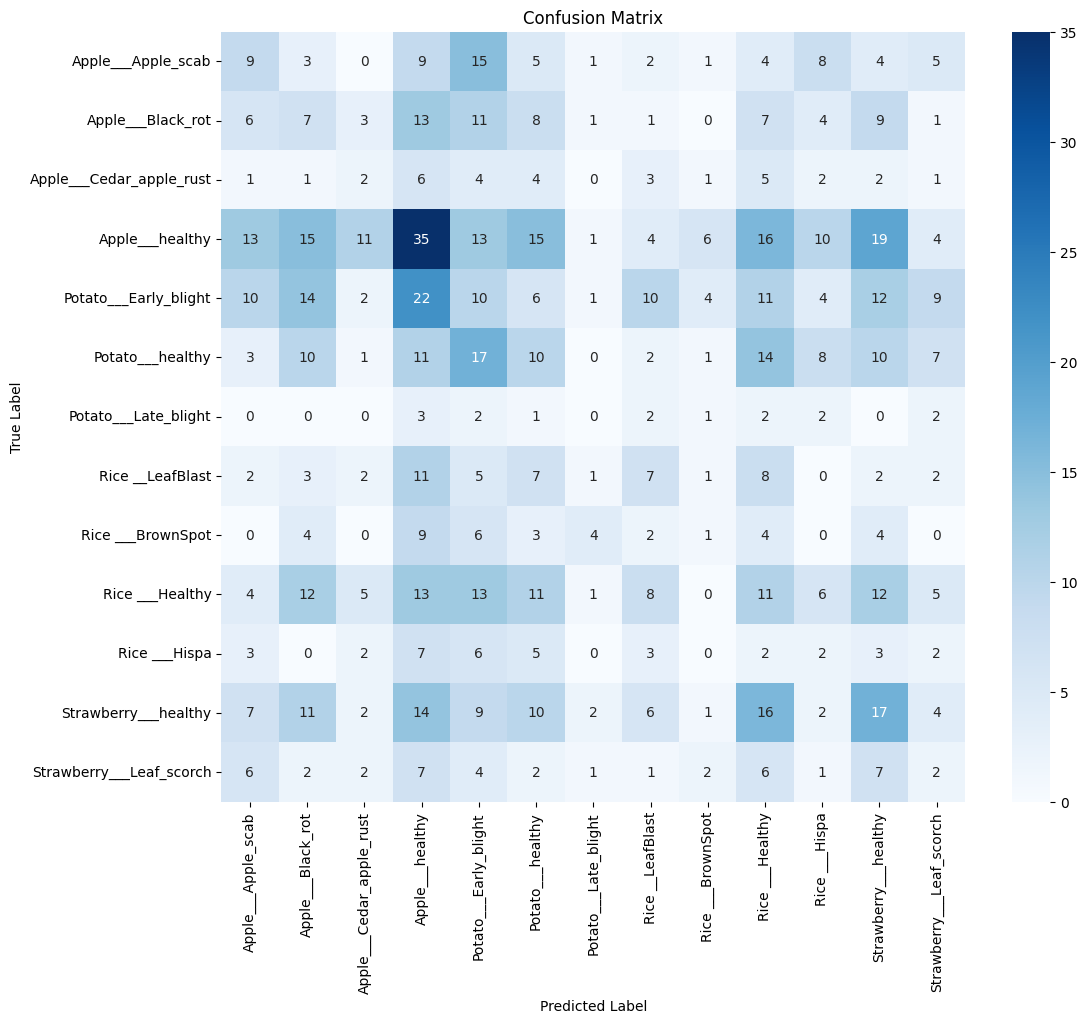

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [33]:
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.12285584040145907
Recall: 0.12242686890574214
F1 Score: 0.1223604891112689


In [34]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.14      0.14      0.14        66
           1       0.09      0.10      0.09        71
           2       0.06      0.06      0.06        32
           3       0.22      0.22      0.22       162
           4       0.09      0.09      0.09       115
           5       0.11      0.11      0.11        94
           6       0.00      0.00      0.00        15
           7       0.14      0.14      0.14        51
           8       0.05      0.03      0.04        37
           9       0.10      0.11      0.11       101
          10       0.04      0.06      0.05        35
          11       0.17      0.17      0.17       101
          12       0.05      0.05      0.05        43

    accuracy                           0.12       923
   macro avg       0.10      0.10      0.10       923
weighted avg       0.12      0.12      0.12       923



In [41]:
import os
model_version=max([int(i) for i in os.listdir("../saved_models") + [0]])+1
model.save(f"../saved_models/{model_version}.h5")


In [42]:
model.save("plant_disease_model.keras")